In [1]:
from backtest_engine import request, Portfolio, PortfolioDynamicCost, StrategyConnector, generate_toy_equity
import numpy as np
from datetime import date
import tomllib

with open("config.toml", "rb") as f:
    config = tomllib.load(f)["alpaca-api"]
    
df = request(
    ticker="SPY",
    config=config,
)

Loading data from local cache: cache_SPY_20170101_20260620.parquet


In [2]:

p = PortfolioDynamicCost(df)
pl = PortfolioDynamicCost(df, short_permissions=False)
ps = PortfolioDynamicCost(df, long_permissions=False)

# long only, leveraged long only, stat arb, market neutral, intraday, momentum
sharpe = np.array([1, 1.6, 5, 2.5, 1.8, 1.2])
volatility = np.array([0.18, 0.26, 0.05, 0.08, 0.12, 0.15])
beta = np.array([0.9, 1.4, 0, 0.1, 0.25, 0.5])

toy_book, filter = generate_toy_equity(
    portfolio=p,
    sharpe=sharpe,
    volatility=volatility,
    beta=beta,
    benchmark=df["close"],
)

for col in toy_book.columns:
    print("\n" + "=" * 90)
    print(f"Stats: {col}")
    print("=" * 90)

    print(f"\n--- {col} | NORMAL (p) ---")
    StrategyConnector(p, toy_book[col], df["close"]).result(plot=False)

    print(f"\n--- {col} | LONG-ONLY (pl) ---")
    StrategyConnector(pl, toy_book[col], df["close"]).result(plot=False)

    print(f"\n--- {col} | SHORT-ONLY (ps) ---")
    StrategyConnector(ps, toy_book[col], df["close"]).result(plot=False)

# print(p.result())
# print(p.result(decompose=True))
# print(p.result(start=date(2020, 1, 1), end=date(2021, 1, 1)))
# print(p.result(day=date(2025, 4, 12)))



Stats: S:1.0|σ:0.180|β:0.9

--- S:1.0|σ:0.180|β:0.9 | NORMAL (p) ---
=== Portfolio Integration & Risk Report ===
                                    Book   Strategy   Combined  Optimised    Bench
Expected Return                   15.57%     18.17%     16.59%     16.74%   14.30%
Volatility                        18.28%     16.07%     11.33%     11.26%   18.45%
Sharpe Ratio                        0.85       1.13       1.46       1.49     0.77
Beta                                0.90      -0.10       0.39       0.32     1.00
Skewness                           -0.19       2.58       0.64       0.89    -0.36
Kurtosis                           11.07      20.65       7.08       7.25    14.94
Max Drawdown                     -29.94%    -15.81%    -16.06%    -14.03%  -34.23%
Max DD Days                          469        255        132        117      512
Max DD Recovery Days                  95        195         91         91      103
Correlation to Book                    -      -0.12     

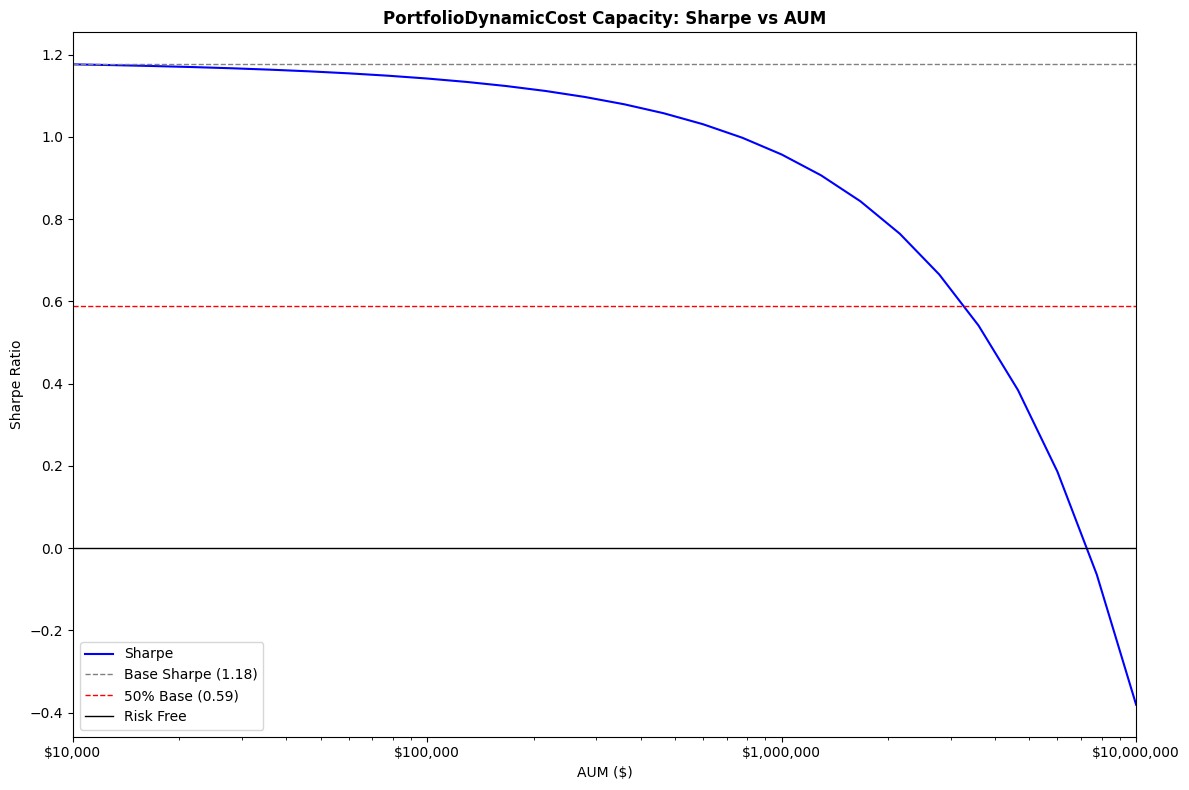

In [3]:
PortfolioDynamicCost.sharpe_curve(df, max_aum=10_000_000)